In [1]:
import pandas as pd

df = pd.read_csv("team_stats_2003_2023.csv")

# NFL seasons were 16 games through 2020 (17 after). win_loss_perc already
# accounts for ties as half-wins, so we don't need wins/losses directly --
# but we do want to know how many ties a team had, since that info is lost
# once wins/losses are dropped below.
df['ties'] = 16 - df['wins'] - df['losses']

# A handful of older seasons are missing 'mov' (margin of victory). It's just
# points_diff averaged over games played, so back-fill it instead of
# dropping those rows.
df['mov'] = df['mov'].fillna(df['points_diff'] / df['g'])

# wins/losses are redundant with win_loss_perc + ties, and year is just a
# season label with no predictive meaning on its own -- drop all three.
df.drop(columns=["wins", "losses", "year"], inplace=True)
df.head()

,team,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,plays_offense,yds_per_play_offense,...,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
0,New England Patriots,0.875,348,238,110,6.9,16,5039,1042,4.8,...,9,3.4,91,111,998,26,27.9,11.3,-136.51,0
1,Miami Dolphins,0.625,311,261,50,3.1,16,4609,968,4.8,...,14,3.7,99,103,913,22,28.1,17.2,-177.92,0
2,Buffalo Bills,0.375,243,279,-36,-2.3,16,4348,980,4.4,...,13,3.9,96,106,891,22,21.9,17.6,-230.07,0
3,New York Jets,0.375,283,299,-16,-1.0,16,4951,936,5.3,...,8,4.0,78,69,550,15,32.4,11.8,-107.89,0
4,Baltimore Ravens,0.625,391,281,110,6.9,16,4929,1009,4.9,...,18,4.8,115,126,970,23,31.8,16.6,-220.50,0


In [2]:
# 'ties' was only computed above to sanity-check the win_loss_perc math --
# it's not used as a feature, so drop it now.
df = df.drop(columns=["ties"])

# 'team' is a categorical string column (32+ franchise names, some of which
# relocated/renamed over the 2003-2023 span, e.g. Redskins -> Football Team
# -> Commanders). One-hot encode it into team_<name> indicator columns so
# models can use team identity without imposing a false numeric ordering.
df = pd.get_dummies(df, columns=["team"], dtype=int)
df.head()

,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,plays_offense,yds_per_play_offense,turnovers,...,team_Pittsburgh Steelers,team_San Diego Chargers,team_San Francisco 49ers,team_Seattle Seahawks,team_St. Louis Rams,team_Tampa Bay Buccaneers,team_Tennessee Titans,team_Washington Commanders,team_Washington Football Team,team_Washington Redskins
0,0.875,348,238,110,6.9,16,5039,1042,4.8,24,...,0,0,0,0,0,0,0,0,0,0
1,0.625,311,261,50,3.1,16,4609,968,4.8,34,...,0,0,0,0,0,0,0,0,0,0
2,0.375,243,279,-36,-2.3,16,4348,980,4.4,34,...,0,0,0,0,0,0,0,0,0,0
3,0.375,283,299,-16,-1.0,16,4951,936,5.3,20,...,0,0,0,0,0,0,0,0,0,0
4,0.625,391,281,110,6.9,16,4929,1009,4.9,38,...,0,0,0,0,0,0,0,0,0,0


## Data Exploration

Before modeling, let's look at how each stat is distributed, how they relate to each other, and how much redundant information they carry. We exclude the one-hot encoded `team_*` indicator columns from all of this — they're categorical identifiers, not continuous stats.

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid", palette="deep")

# Exclude the one-hot encoded team_* dummy columns -- those are categorical
# indicators, not continuous stats, so they don't belong in the distribution/
# correlation/regression analysis below.
stat_cols = [c for c in df.columns if not c.startswith("team_")]

### Distributions + Gaussian fit

Histogram of each stat with a Gaussian fit (μ, σ) overlaid.

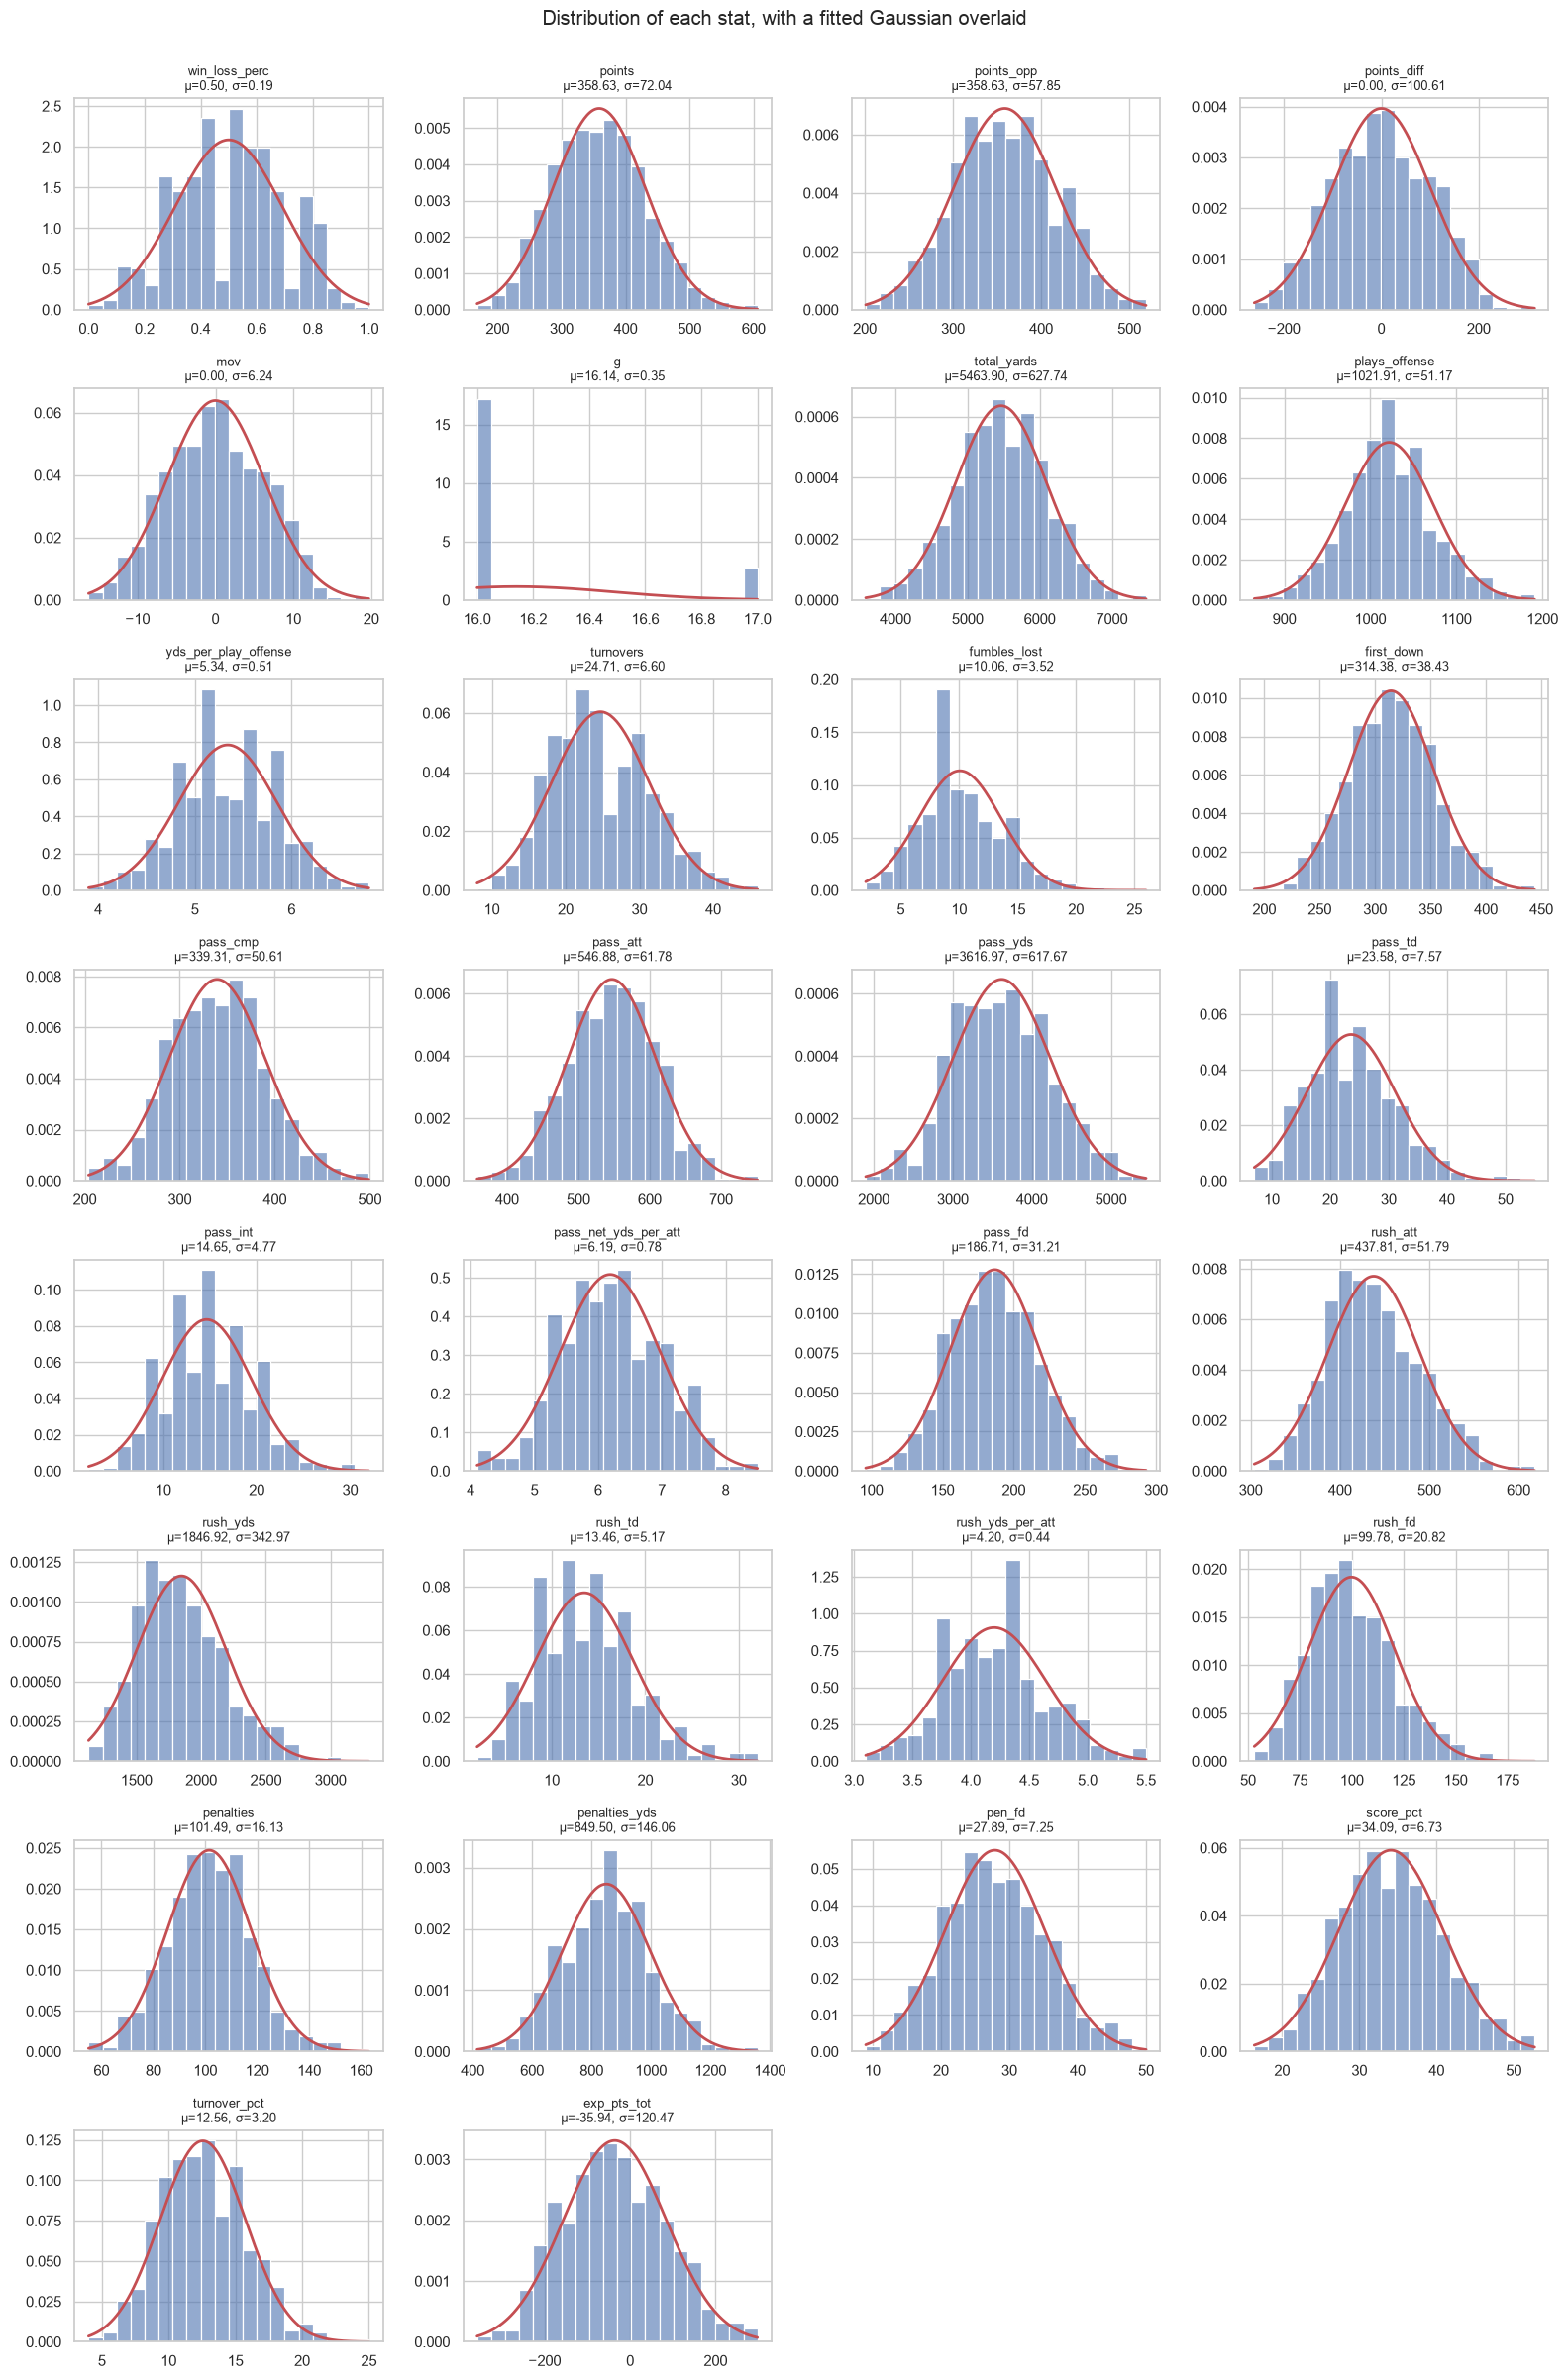

In [4]:
n_cols = 4
n_rows = int(np.ceil(len(stat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, stat_cols):
    data = df[col].dropna()
    mu, sigma = stats.norm.fit(data)

    sns.histplot(data, stat="density", bins=20, color="#4C72B0", alpha=0.6, ax=ax)

    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="#C44E52", lw=2)

    ax.set_title(f"{col}\nμ={mu:.2f}, σ={sigma:.2f}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# hide any unused subplot slots
for ax in axes[len(stat_cols):]:
    ax.axis("off")

fig.suptitle("Distribution of each stat, with a fitted Gaussian overlaid", y=1.0)
plt.tight_layout()
plt.show()

### Comparing spread on a shared scale

Standardizing each column (z-score) puts them on a shared mean (0) and shared scale, so we can compare their shapes directly against a true Gaussian (dashed) and see which stats deviate more from normal — plus a summary of relative variability (coefficient of variation) below, since raw std isn't comparable across columns with very different units.

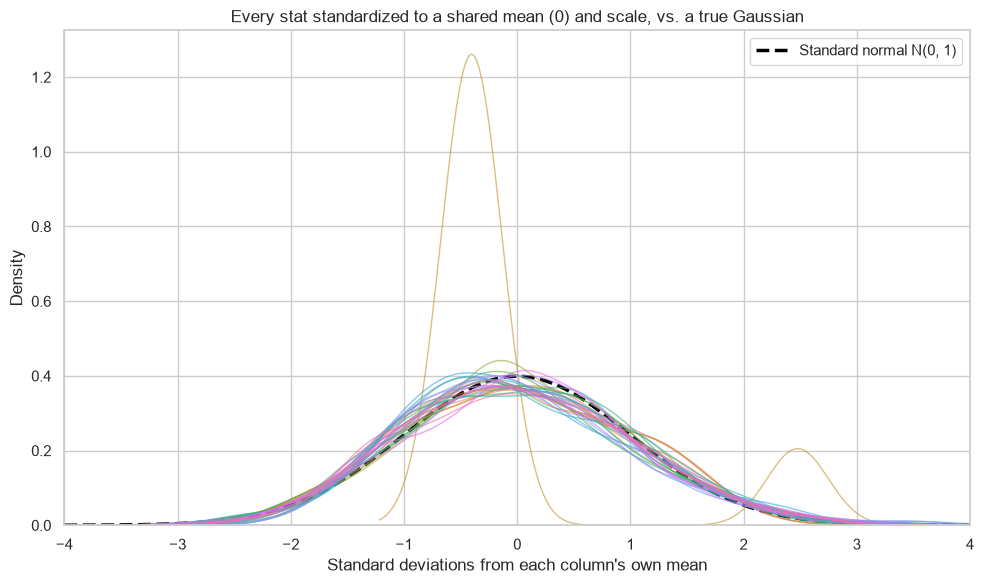

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-4, 4, 200)
ax.plot(x, stats.norm.pdf(x, 0, 1), color="black", lw=2.5, ls="--", label="Standard normal N(0, 1)")

palette = sns.color_palette("husl", len(stat_cols))
for col, color in zip(stat_cols, palette):
    data = df[col].dropna()
    z = (data - data.mean()) / data.std()
    sns.kdeplot(z, ax=ax, color=color, lw=1, alpha=0.6)

ax.set_xlim(-4, 4)
ax.set_title("Every stat standardized to a shared mean (0) and scale, vs. a true Gaussian")
ax.set_xlabel("Standard deviations from each column's own mean")
ax.legend()
plt.tight_layout()
plt.show()

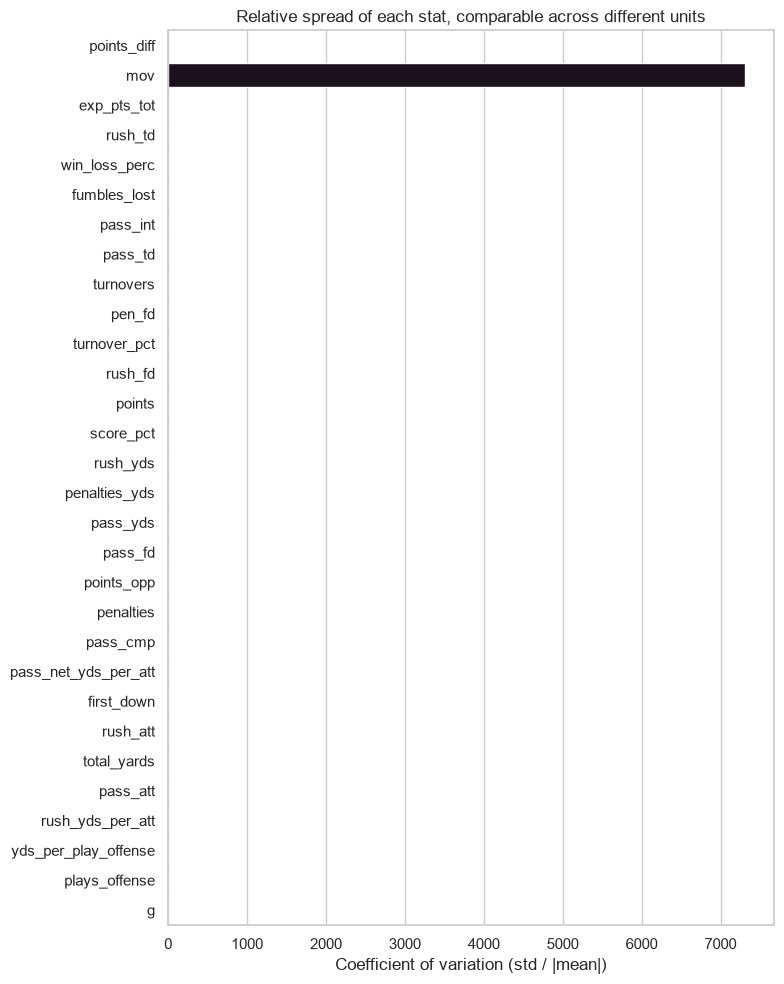

,mean,std,cv
points_diff,0.000000,100.684601,inf
mov,0.000855,6.248569,7312.025392
exp_pts_tot,-35.937113,120.556255,3.354645
rush_td,13.462798,5.170285,0.384042
win_loss_perc,0.500246,0.191452,0.382716
fumbles_lost,10.062500,3.517759,0.349591
pass_int,14.645833,4.775388,0.326058
pass_td,23.580357,7.579648,0.321439
turnovers,24.708333,6.604748,0.267309
pen_fd,27.889881,7.251892,0.260019


In [6]:
summary = pd.DataFrame({
    "mean": df[stat_cols].mean(),
    "std": df[stat_cols].std(),
})
# Coefficient of variation (std / |mean|) so spread is comparable across
# columns that live on very different scales (e.g. total_yards vs win_loss_perc).
summary["cv"] = summary["std"] / summary["mean"].abs()
summary = summary.sort_values("cv", ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(x=summary["cv"], y=summary.index, hue=summary.index, palette="mako", legend=False, ax=ax)
ax.set_xlabel("Coefficient of variation (std / |mean|)")
ax.set_ylabel("")
ax.set_title("Relative spread of each stat, comparable across different units")
plt.tight_layout()
plt.show()

summary

### Correlation between stats

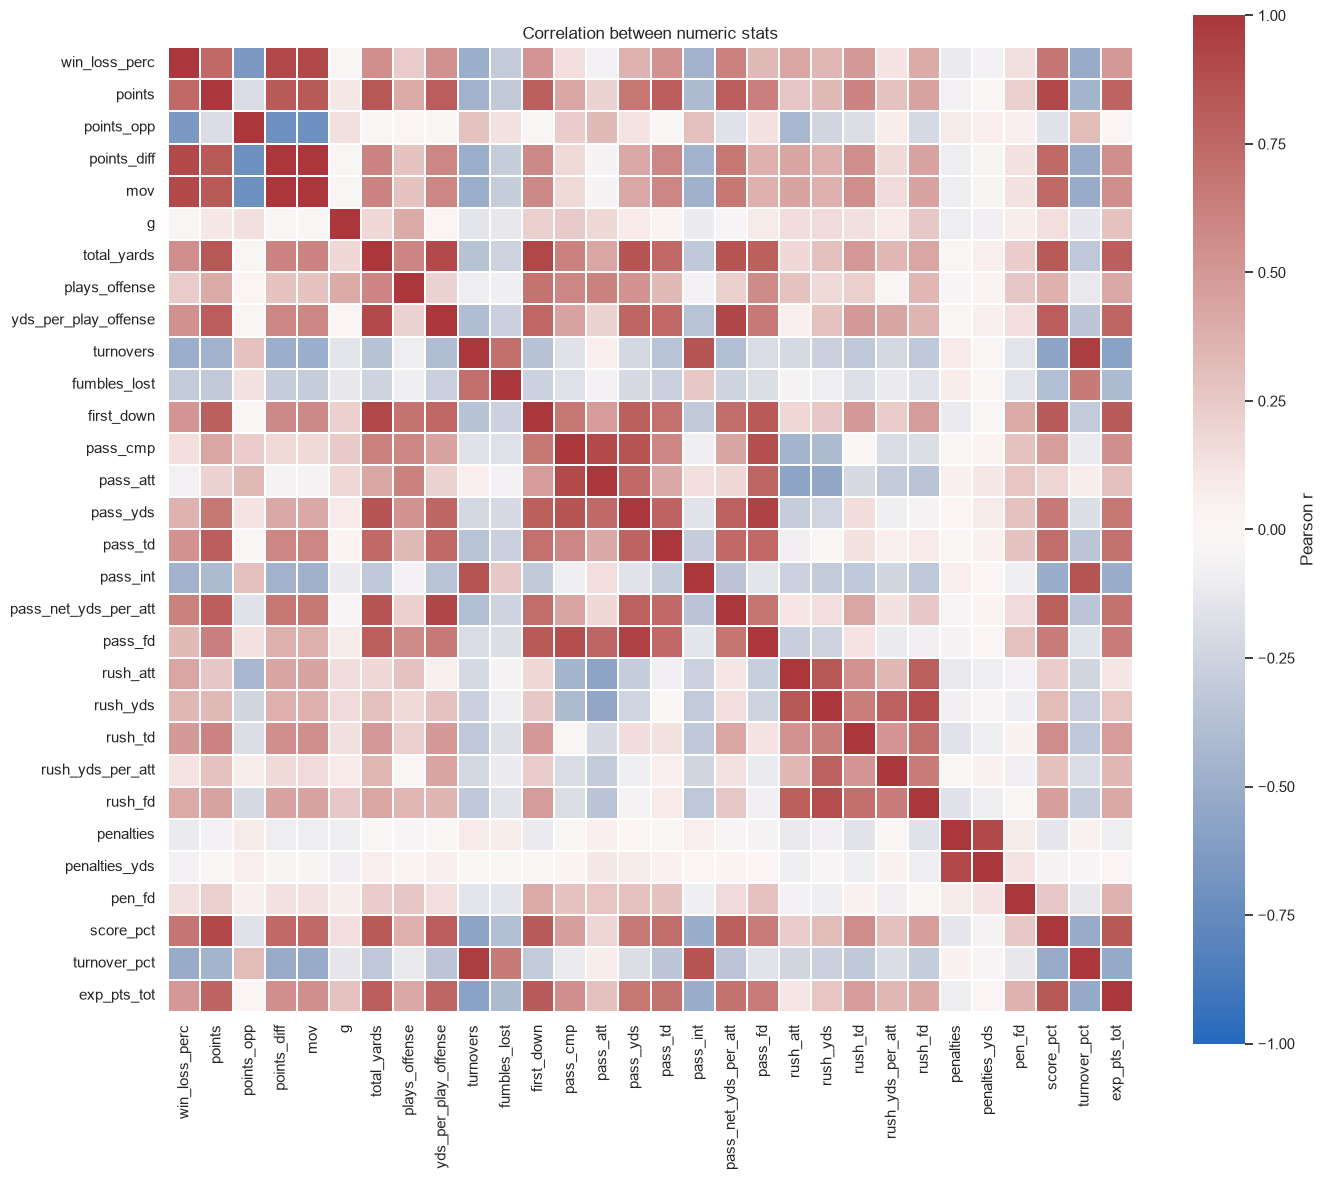

In [7]:
corr = df[stat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.3, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation between numeric stats")
plt.tight_layout()
plt.show()

### How redundant is each stat, given the rest?

For each stat, fit a linear regression predicting it from all the *other* numeric stats (excluding `team_*`) and record the R². A high R² means that column is largely reconstructable from the rest of the table — i.e. it's carrying redundant information.

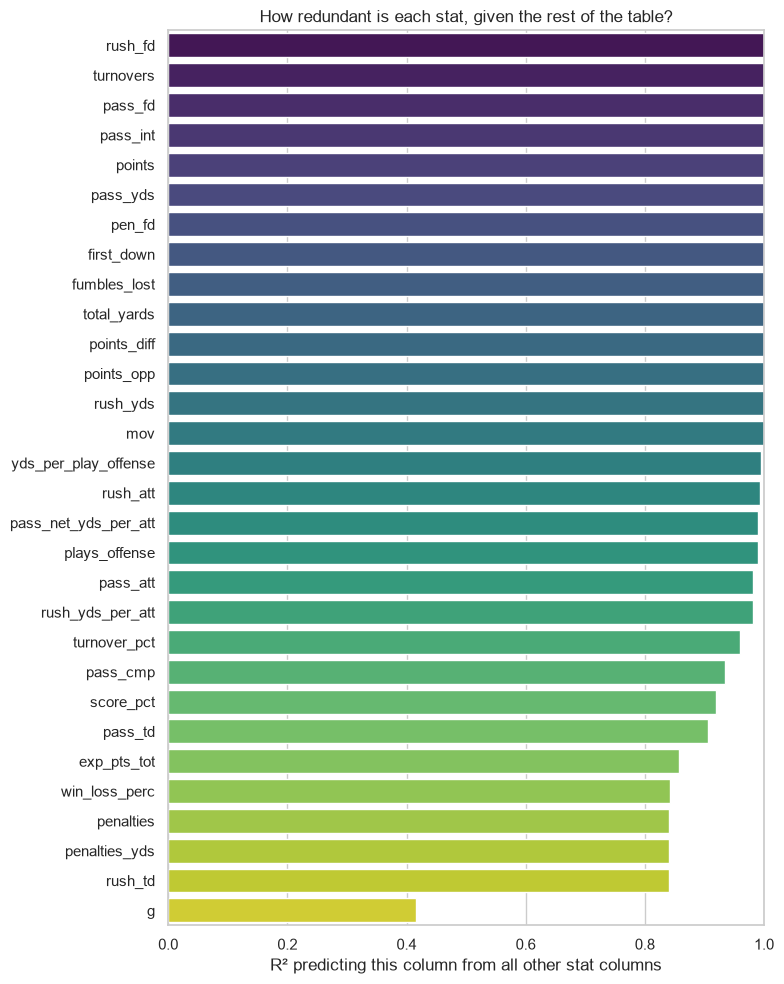

In [8]:
# For each stat, see how well it can be reconstructed (R^2) from all the
# OTHER stat columns via linear regression. A high R^2 means that column
# carries little information beyond what's already in the rest of the table.
r2_scores = {}
for col in stat_cols:
    X_other = df[stat_cols].drop(columns=[col])
    y_col = df[col]

    lr = LinearRegression()
    lr.fit(X_other, y_col)
    r2_scores[col] = r2_score(y_col, lr.predict(X_other))

r2_df = pd.Series(r2_scores, name="R^2").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(x=r2_df.values, y=r2_df.index, hue=r2_df.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("R² predicting this column from all other stat columns")
ax.set_ylabel("")
ax.set_title("How redundant is each stat, given the rest of the table?")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

In [9]:
# Mean-center every column (including the team_* dummies), then scale by
# each column's max absolute value so everything ends up roughly in [-1, 1].
# This puts wildly different-scale stats (e.g. total_yards ~5000 vs
# win_loss_perc ~0-1) on comparable footing before fitting models that are
# sensitive to feature scale (regularized/linear models, the neural net).
df = df - df.mean()
df = df / df.abs().max()
df.head()

,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,plays_offense,yds_per_play_offense,turnovers,...,team_Pittsburgh Steelers,team_San Diego Chargers,team_San Francisco 49ers,team_Seattle Seahawks,team_St. Louis Rams,team_Tampa Bay Buccaneers,team_Tennessee Titans,team_Washington Commanders,team_Washington Football Team,team_Washington Redskins
0,0.749141,-0.042989,-0.752241,0.349206,0.350226,-0.16263,-0.211380,0.118809,-0.370310,-0.033268,...,-0.032258,-0.021277,-0.032258,-0.032258,-0.019727,-0.032258,-0.032258,-0.002985,-0.002985,-0.025954
1,0.249386,-0.192565,-0.608819,0.158730,0.157324,-0.16263,-0.425299,-0.318830,-0.370310,0.436399,...,-0.032258,-0.021277,-0.032258,-0.032258,-0.019727,-0.032258,-0.032258,-0.002985,-0.002985,-0.025954
2,-0.250368,-0.467461,-0.496576,-0.114286,-0.116800,-0.16263,-0.555143,-0.247861,-0.644372,0.436399,...,-0.032258,-0.021277,-0.032258,-0.032258,-0.019727,-0.032258,-0.032258,-0.002985,-0.002985,-0.025954
3,-0.250368,-0.305757,-0.371861,-0.050794,-0.050807,-0.16263,-0.255159,-0.508079,-0.027732,-0.221135,...,-0.032258,-0.021277,-0.032258,-0.032258,-0.019727,-0.032258,-0.032258,-0.002985,-0.002985,-0.025954
4,0.249386,0.130843,-0.484104,0.349206,0.350226,-0.16263,-0.266104,-0.076354,-0.301794,0.624266,...,-0.032258,-0.021277,-0.032258,-0.032258,-0.019727,-0.032258,-0.032258,-0.002985,-0.002985,-0.025954


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=["win_loss_perc"])
y = df["win_loss_perc"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)
print("Multiple Linear Regression")
print("R^2:", r2_score(y_test, y_pred_lin))
print("RMSE:", mean_squared_error(y_test, y_pred_lin) ** 0.5)

Multiple Linear Regression
R^2: 0.8430189247869053
RMSE: 0.15644651501662818
